# Tutorial 2: Architectural Discovery with Block-Based Search

In the previous tutorial, we fine-tuned a known architecture (MLP). But what if the best architecture for our problem is a combination of different diverse layer types?

In this notebook, we'll unleash SNAC-pack to **discover new architectures** by combining building blocks like **Convolutional layers**, **Attention**, and **MLPs**.

## The New Challenge

Since we are building arbitrary structures, our hardware estimator may not be accurate. We will instead optimize for two hardware-agnostic objectives:
1.  **Accuracy** (Maximize)
2.  **Computational Cost (BOPs)** (Minimize)

In [1]:

# Basic imports and setup
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_local_search_separated import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist
import seaborn as sns



# --- Configuration ---
N_TRIALS_HYBRID = 6 # Note: Increase for a real search
EPOCHS_HYBRID = 10
SUBSET_SIZE_HYBRID = 20000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-08-31 16:45:50.361605: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000,), y_val shape: (10000,)


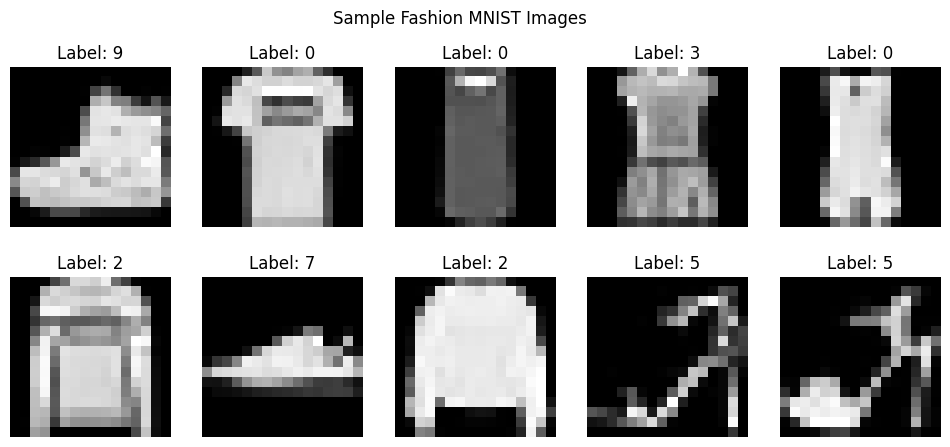

In [2]:

# Load the data for visualization (un-flattened)
x_train_viz, y_train_viz, _, _ = load_and_preprocess_fashion_mnist(
    resize_val=RESIZE_VAL,
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False, 
    one_hot=False
)

# Visualize the first 10 images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample Fashion MNIST Images")
plt.show()

## Global Search: Building with Blocks

We first define a `search_space` in a YAML file. This file provides SNAC-pack with the "Lego bricks" it can use to build and test new architectures. We'll allow it to choose between `Conv`, `MLP`, and `ConvAttn` blocks.


In [3]:

# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
channel_space: [8, 16, 32]
mlp_width_space: [32, 64, 128]
kernel_space: [1, 3, 5]
act_space: ["ReLU", "GELU", "LeakyRelu"]
norm_space: [null, "batch", "layer"]
block_types: ["Conv", "MLP", "None"]
num_blocks: 5
initial_img_size: 16
output_dim: 10
"""
# search_space_yaml = """
# channel_space: [8, 16, 32]
# mlp_width_space: [32, 64, 128]
# kernel_space: [1, 3, 5]
# act_space: ["ReLU","GELU", "LeakyRelu" ]
# norm_space: [null]
# block_types: ["Conv", "MLP", "None"]
# num_blocks: 8
# initial_img_size: 16
# output_dim: 10
# """

with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops']
MAXIMIZE_FLAGS_HYBRID = [True, False]

# --- Run the Hybrid Search ---
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Global Search...")
print("This will take several minutes...")
print("="*50)

searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

study_hybrid = searcher_hybrid.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='fashion_mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_hybrid.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    one_hot=True,
)

print("\nGlobal Search Complete!")

Created search space configuration file: hybrid_search_space.yaml

Running Part 2: Hybrid Architecture Global Search...
This will take several minutes...

Starting BLOCK Global Search on FASHION_MNIST



[I 2025-08-31 16:45:56,330] A new study created in memory with name: no-name-47e7a72a-f9ab-4e33-8888-279739681dec


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)


[I 2025-08-31 16:46:01,185] Trial 0 finished with values: [0.7498000264167786, 50593792.0] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'Conv', 'b3': 'Conv', 'b4': 'MLP', 'b0_MLP_units': 2, 'b0_MLP_act': 'LeakyRelu', 'b0_MLP_norm': 'layer', 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': 'layer', 'b4_MLP_units': 0, 'b4_MLP_act': 'LeakyRelu', 'b4_MLP_norm': 'batch', 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 0: Accuracy=0.7498, BOPs=50593792


...

Trial 3: Accuracy=0.7824, BOPs=23396352


[I 2025-08-31 16:47:14,805] Trial 4 finished with values: [0.7925999760627747, 363069440.0] and parameters: {'b0': 'Conv', 'b1': 'MLP', 'b2': 'None', 'b3': 'Conv', 'b4': 'Conv', 'b0_Conv_channels_0': 1, 'b0_Conv_channels_1': 1, 'b0_Conv_kernels_0': 5, 'b0_Conv_kernels_1': 1, 'b0_Conv_acts_0': 'ReLU', 'b0_Conv_acts_1': 'LeakyRelu', 'b0_Conv_norms_0': 'layer', 'b0_Conv_norms_1': None, 'b1_MLP_units': 2, 'b1_MLP_act': 'LeakyRelu', 'b1_MLP_norm': 'batch', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'layer'}.


Trial 4: Accuracy=0.7926, BOPs=363069440


[I 2025-08-31 16:47:21,800] Trial 5 finished with values: [0.6739000082015991, 34209792.0] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'MLP', 'b4': 'MLP', 'b0_MLP_units': 0, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': 'layer', 'b1_MLP_units': 1, 'b1_MLP_act': 'GELU', 'b1_MLP_norm': None, 'b2_MLP_units': 1, 'b2_MLP_act': 'LeakyRelu', 'b2_MLP_norm': 'batch', 'b3_MLP_units': 0, 'b3_MLP_act': 'ReLU', 'b3_MLP_norm': 'layer', 'b4_MLP_units': 2, 'b4_MLP_act': 'LeakyRelu', 'b4_MLP_norm': 'layer', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'layer'}.


Trial 5: Accuracy=0.6739, BOPs=34209792

CSV results saved to ./results/tutorial2_Hybrid_Discovery/block_search_results.csv

🏆 Best model architecture (Trial 4) saved for local search:
   - Source: ./results/tutorial2_Hybrid_Discovery/trial_4_arch.yaml
   - Destination: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml
   - Accuracy: 0.7926

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 3):
  Values: {'performance_metric': 0.7824000120162964, 'bops': 23396352.0}
  Params: {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3': 'Conv', 'b4': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'LeakyRelu', 'b0_MLP_norm': 'batch', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'layer'}

Rank 2 (Trial 4):
  Values: {'performance_metric': 0.7925999760627747, 'bops': 363069440.0}
  Params: {'b0': 'Conv', 'b1': 'MLP', 'b2': 

## Analyzing the Global Search Results

The search has finished exploring different architectural combinations. Let's see what it found!

In [4]:


results_df_hybrid = pd.DataFrame(searcher_hybrid.results)

if not results_df_hybrid.empty:
    # --- Inspect the Best Discovered Architecture ---
    print("--- Best Discovered Architecture (by Accuracy) ---")
    best_trial_row = results_df_hybrid.loc[results_df_hybrid['performance_metric'].idxmax()]
    print(f"Trial Number: {best_trial_row['trial']}")
    print(f"Accuracy: {best_trial_row['performance_metric']:.4f}")
    print(f"BOPs: {best_trial_row['bops']:.2e}")

    # Load and print the architecture from its YAML file
    with open(best_trial_row['yaml_path'], 'r') as f:
        best_arch_yaml = yaml.safe_load(f)

    print("\nArchitecture components:")
    for component in best_arch_yaml['architecture']['components']:
        print(f"- Type: {component['block_type']}, Name: {component['name']}")

    # --- Visualize the Pareto Front (Accuracy vs BOPs) ---
    print("\n--- Generating Interactive Pareto Front Plot for Hybrid Search ---")
    plot_interactive_2d_pareto(
        results_df_hybrid,
        list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID)),
        save_dir=searcher_hybrid.results_dir
    )
else:
    print("Hybrid search did not yield any results to analyze.")

--- Best Discovered Architecture (by Accuracy) ---
Trial Number: 4
Accuracy: 0.7926
BOPs: 3.63e+08

Architecture components:
- Type: Conv, Name: conv_block_0
- Type: Flatten, Name: initial_flatten
- Type: MLP, Name: mlp_block_1
- Type: MLP, Name: classifier_head

--- Generating Interactive Pareto Front Plot for Hybrid Search ---
Interactive 2D Pareto front plot saved to ./results/tutorial2_Hybrid_Discovery/interactive_pareto_front_2d.html


## Local Search: Compressing Our New Discovery

Just like before, the global search saved the best model. We will now apply the same powerful QAT and pruning techniques to this newly discovered hybrid model, demonstrating the consistent workflow of SNAC-pack.


In [1]:

# Basic imports and setup
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_local_search_separated2 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist
import seaborn as sns



# --- Configuration ---
N_TRIALS_HYBRID = 6 # Note: Increase for a real search
EPOCHS_HYBRID = 10
SUBSET_SIZE_HYBRID = 20000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-08-31 17:44:23.926432: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Configuration for Separated Local Search ---
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_HYBRID, "local_search_separated")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_HYBRID, 'local_search_settings_separated.yaml')

# Define settings for QAT only
local_search_settings = {
    'qat_settings': {
        'epochs': 10, # Epochs to fine-tune each quantized model
        'precision_pairs': [
            {'total_bits': 16, 'int_bits': 6},
            {'total_bits': 8, 'int_bits': 3},
            {'total_bits': 4, 'int_bits': 1},
        ]
    }
}

# Write the new settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created separated local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

# --- Load Dataset for Local Search ---
searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

resize_val = searcher_hybrid.search_space.get('initial_img_size', 11)
x_train, y_train, x_val, y_val = load_and_preprocess_fashion_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False,
    one_hot=True
)

# --- Run the Separated Local Search ---
if os.path.exists(ARCHITECTURE_YAML_PATH):
    # Run QAT-only local search
    _, qat_results_df_hybrid = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR,
        run_pruning=False # <-- Key change: disable pruning
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    pruning_results_df_hybrid, qat_results_df_hybrid = pd.DataFrame(), pd.DataFrame()


Created separated local search configuration file: ./results/tutorial2_Hybrid_Discovery/local_search_settings_separated.yaml
Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)

 STARTING SEPARATED LOCAL SEARCH STAGE 

-------------------- Starting QAT-Only Experiment --------------------

Running QAT for Precision: <16,6>
--> Fine-tuning QAT model for 10 epochs...
Epoch 1/10
157/157 [==============================] - 4s 15ms/step - loss: 6.2930 - accuracy: 0.1963 - val_loss: 5.0697 - val_accuracy: 0.2102
Epoch 2/10
157/157 [==============================] - 2s 12ms/step - loss: 3.6778 - accuracy: 0.3771 - val_loss: 3.4043 - val_accuracy: 0.4629
Epoch 3/10
157/157 [==============================] - 2s 12ms/step - loss: 3.2446 - accuracy: 0.5024 - val_loss: 3.0899 - val_accuracy: 0.5539
Epoch 4/10
157/157 [==============================] - 2s 13ms/step - loss: 3.0382 - a

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


--> Fine-tuning QAT model for 10 epochs...
Epoch 1/10
157/157 [==============================] - 4s 15ms/step - loss: 5.2851 - accuracy: 0.2388 - val_loss: 3.8882 - val_accuracy: 0.3425
Epoch 2/10
157/157 [==============================] - 2s 12ms/step - loss: 3.5547 - accuracy: 0.4067 - val_loss: 3.6722 - val_accuracy: 0.3848
Epoch 3/10
157/157 [==============================] - 2s 11ms/step - loss: 3.3879 - accuracy: 0.4496 - val_loss: 3.2295 - val_accuracy: 0.5013
Epoch 4/10
157/157 [==============================] - 2s 11ms/step - loss: 3.2097 - accuracy: 0.5072 - val_loss: 3.1331 - val_accuracy: 0.5191
Epoch 5/10
157/157 [==============================] - 2s 12ms/step - loss: 3.1022 - accuracy: 0.5394 - val_loss: 3.0381 - val_accuracy: 0.5459
Epoch 6/10
157/157 [==============================] - 2s 11ms/step - loss: 2.9898 - accuracy: 0.5612 - val_loss: 2.9428 - val_accuracy: 0.5709
Epoch 7/10
157/157 [==============================] - 2s 11ms/step - loss: 2.9281 - accuracy: 0.575

/tmp/ipykernel_816716/1432059011.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Accuracy', data=qat_results_df_hybrid, palette=palette)


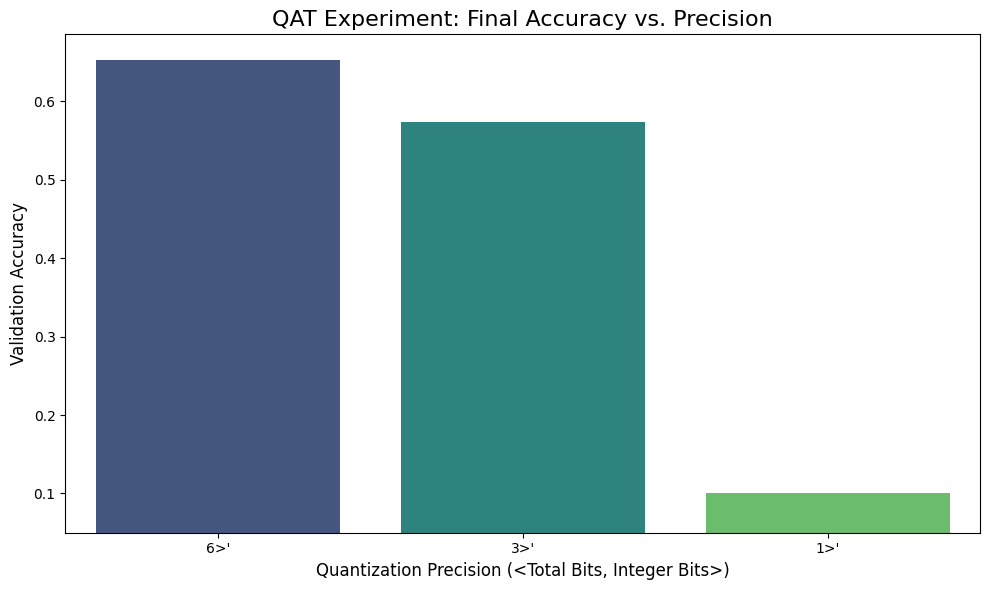

In [3]:
# --- Plot QAT Results (Accuracy per Precision) ---
if 'qat_results_df_hybrid' in locals() and not qat_results_df_hybrid.empty:
    plt.figure(figsize=(10, 6))
    
    # Create the bar plot
    import seaborn as sns
    palette = sns.color_palette("viridis", n_colors=len(qat_results_df_hybrid))
    sns.barplot(x='Precision', y='Accuracy', data=qat_results_df_hybrid, palette=palette)
    
    # Baseline accuracy from pruning is no longer available or plotted.
    
    plt.title('QAT Experiment: Final Accuracy vs. Precision', fontsize=16)
    plt.xlabel('Quantization Precision (<Total Bits, Integer Bits>)', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.ylim(bottom=max(0, qat_results_df_hybrid['Accuracy'].min() - 0.05))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("QAT experiment did not produce results to analyze.")